In [7]:
import pandas as pd
import matplotlib.pyplot as plt

In [8]:
df = pd.read_csv('proact_preprocessed_S1.csv')
df.head()

,subject_id,ALSFRS_Delta,Q1_Speech,Q2_Salivation,Q3_Swallowing,Q4_Handwriting,Q5_Cutting,Q6_Dressing_and_Hygiene,Q7_Turning_in_Bed,Q8_Walking,Q9_Climbing_Stairs,R_1_Dyspnea,R_2_Orthopnea,R_3_Respiratory_Insufficiency,Age_Base,Sex_Female,Treatment_Active,Bulbar_Onset,FVC_Base,BMI_Base
0,16497,0.0,4.0,4.0,4.0,3.0,3.0,2.0,1.0,1.0,0.0,4.0,4.0,4.0,0.016919,1.0,1.0,0.0,0.126976,-0.356485
1,53215,8.0,3.0,2.0,4.0,4.0,4.0,3.0,3.0,3.0,3.0,4.0,4.0,4.0,-1.013892,0.0,1.0,1.0,0.289065,-0.354520
2,53215,71.0,3.0,2.0,4.0,3.0,4.0,3.0,3.0,3.0,1.0,4.0,4.0,4.0,-1.013892,0.0,1.0,1.0,0.289065,-0.354520
3,53215,140.0,3.0,3.0,4.0,3.0,4.0,2.0,3.0,3.0,3.0,3.0,4.0,4.0,-1.013892,0.0,1.0,1.0,0.289065,-0.354520
4,53215,204.0,3.0,4.0,3.0,3.0,3.0,3.0,3.0,2.0,2.0,4.0,4.0,4.0,-1.013892,0.0,1.0,1.0,0.289065,-0.354520


In [9]:
import pandas as pd
import statsmodels.formula.api as smf

# 1. Create the Total Score by summing all 12 ALSFRS-R questions
# (Assuming the 'alsfrs_dimensions' list from the first step is still defined)
alsfrs_dimensions = [
    'Q1_Speech', 'Q2_Salivation', 'Q3_Swallowing', 'Q4_Handwriting',
    'Q5_Cutting', 'Q6_Dressing_and_Hygiene', 'Q7_Turning_in_Bed',
    'Q8_Walking', 'Q9_Climbing_Stairs', 'R_1_Dyspnea',
    'R_2_Orthopnea', 'R_3_Respiratory_Insufficiency'
]

df['ALSFRS_Total'] = df[alsfrs_dimensions].sum(axis=1)

# 2. Define the formula (Target ~ Covariates)
covariates = 'ALSFRS_Delta + Sex_Female + Treatment_Active + Age_Base + Bulbar_Onset + FVC_Base + BMI_Base'
formula_total = f"ALSFRS_Total ~ {covariates}"

# 3. Fit the Linear Mixed Effects Model
print("Fitting LMM for Total ALSFRS-R Score...")
try:
    model_total = smf.mixedlm(formula_total, data=df, groups=df["subject_id"])
    result_total = model_total.fit()
    
    print("\n" + "="*60)
    print("SUMMARY: TOTAL ALSFRS-R SCORE (0-48 Scale)")
    print("="*60)
    print(result_total.summary())
    
except Exception as e:
    print(f"Failed to fit Total Score model. Error: {e}")

Fitting LMM for Total ALSFRS-R Score...



SUMMARY: TOTAL ALSFRS-R SCORE (0-48 Scale)
           Mixed Linear Model Regression Results
Model:              MixedLM Dependent Variable: ALSFRS_Total
No. Observations:   4336    Method:             REML        
No. Groups:         775     Scale:              8.1453      
Min. group size:    1       Log-Likelihood:     -11902.5552 
Max. group size:    10      Converged:          Yes         
Mean group size:    5.6                                     
------------------------------------------------------------
                 Coef.  Std.Err.    z    P>|z| [0.025 0.975]
------------------------------------------------------------
Intercept        38.912    0.474  82.119 0.000 37.984 39.841
ALSFRS_Delta     -0.028    0.001 -54.766 0.000 -0.029 -0.027
Sex_Female       -1.135    0.466  -2.435 0.015 -2.048 -0.221
Treatment_Active -0.129    0.506  -0.255 0.798 -1.121  0.863
Age_Base          0.165    0.227   0.727 0.467 -0.279  0.609
Bulbar_Onset      0.462    0.602   0.768 0.443 -0.717

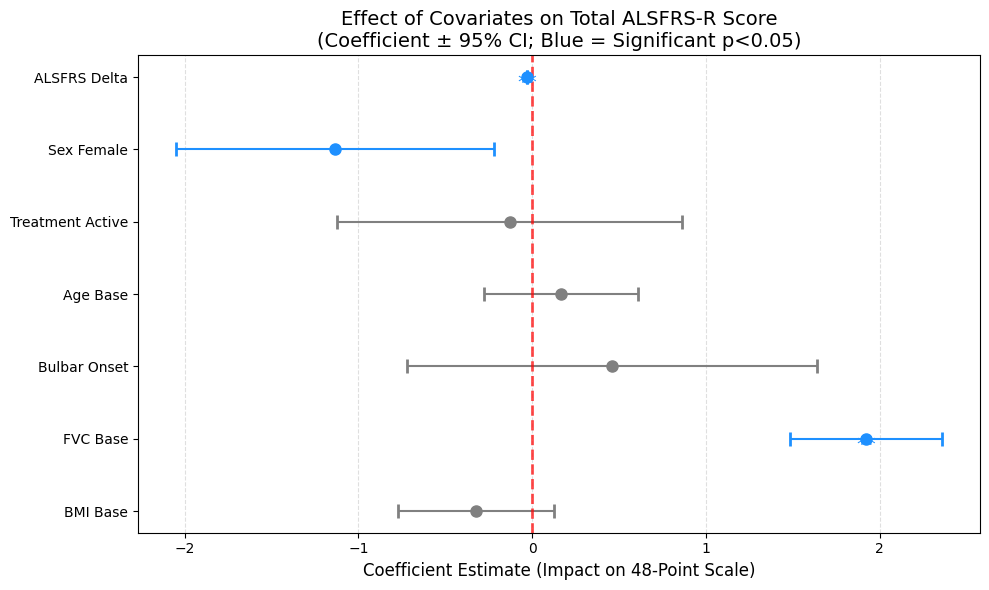

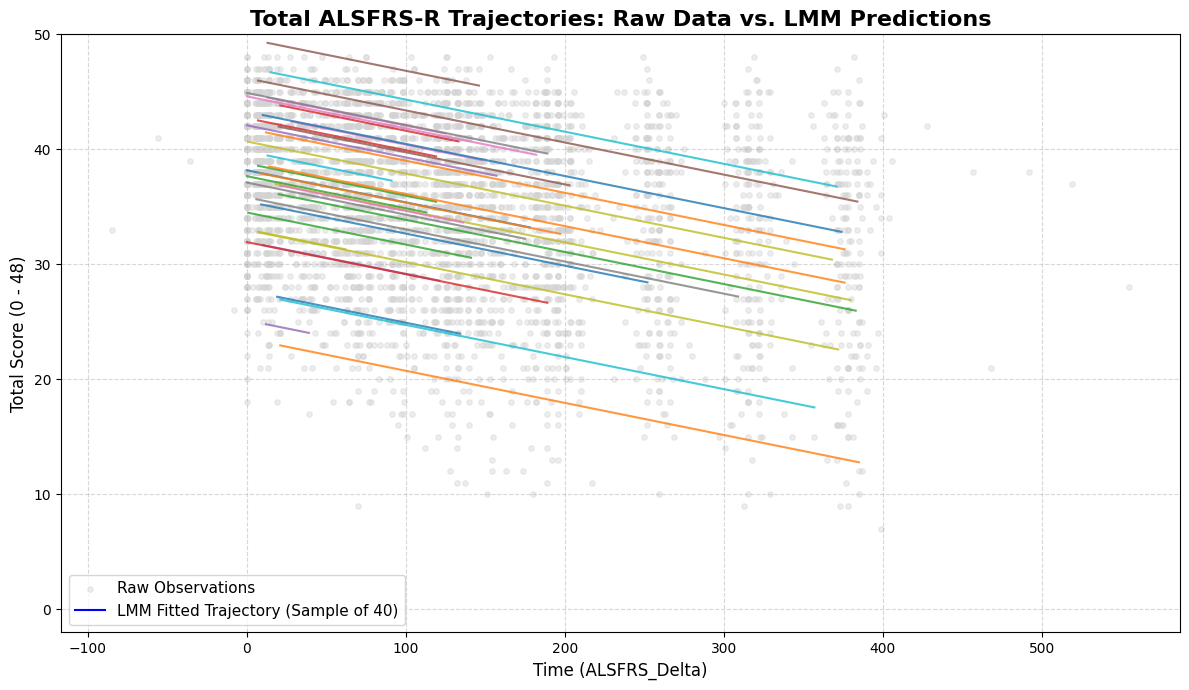

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# A. FOREST PLOT OF ALL COVARIATES
# ==========================================
# Extract parameters, confidence intervals, and p-values
params = result_total.params.drop(['Intercept', 'Group Var'])
conf_int = result_total.conf_int().loc[params.index]
p_values = result_total.pvalues.loc[params.index]

# Calculate error bounds for plotting
err_low = params - conf_int[0]
err_upp = conf_int[1] - params

plt.figure(figsize=(10, 6))

# Define colors based on statistical significance (p < 0.05)
colors = ['dodgerblue' if p < 0.05 else 'gray' for p in p_values]

# Plot error bars
for i, covariate in enumerate(params.index):
    plt.errorbar(x=params[covariate], y=i, 
                 xerr=[[err_low[covariate]], [err_upp[covariate]]], 
                 fmt='o', color=colors[i], ecolor=colors[i], 
                 capsize=5, capthick=2, markersize=8)
    
    # Add significance asterisks
    if p_values[covariate] < 0.01:
        plt.text(params[covariate], i + 0.15, '**', ha='center', color=colors[i], fontsize=14)
    elif p_values[covariate] < 0.05:
        plt.text(params[covariate], i + 0.15, '*', ha='center', color=colors[i], fontsize=14)

# Formatting
plt.yticks(range(len(params.index)), params.index.str.replace('_', ' '))
plt.axvline(x=0, color='red', linestyle='--', alpha=0.7, linewidth=2)
plt.title('Effect of Covariates on Total ALSFRS-R Score\n(Coefficient ± 95% CI; Blue = Significant p<0.05)', fontsize=14)
plt.xlabel('Coefficient Estimate (Impact on 48-Point Scale)', fontsize=12)
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# ==========================================
# B. TRAJECTORY SCATTER PLOT
# ==========================================
plt.figure(figsize=(12, 7))

# Plot raw data points in the background
plt.scatter(df['ALSFRS_Delta'], df['ALSFRS_Total'], 
            color='lightgray', alpha=0.4, s=15, label='Raw Observations')

# Extract fitted values
df_plot = df[['subject_id', 'ALSFRS_Delta', 'ALSFRS_Total']].copy()
df_plot['fitted'] = result_total.fittedvalues

# Sample 40 random subjects for the fitted lines
np.random.seed(42)
sample_subjects = np.random.choice(df['subject_id'].unique(), size=40, replace=False)
subset = df_plot[df_plot['subject_id'].isin(sample_subjects)]

# Draw the LMM trajectories
for subject in sample_subjects:
    subj_data = subset[subset['subject_id'] == subject].sort_values('ALSFRS_Delta')
    if not subj_data.empty:
        plt.plot(subj_data['ALSFRS_Delta'], subj_data['fitted'], alpha=0.8, linewidth=1.5)

# Add a fake line for the legend
plt.plot([], [], color='blue', label='LMM Fitted Trajectory (Sample of 40)')

# Formatting
plt.title('Total ALSFRS-R Trajectories: Raw Data vs. LMM Predictions', fontsize=16, fontweight='bold')
plt.xlabel('Time (ALSFRS_Delta)', fontsize=12)
plt.ylabel('Total Score (0 - 48)', fontsize=12)
plt.ylim(-2, 50) # Standard scale is 0-48
plt.legend(loc='lower left', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [11]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_squared_error

# Define the three scenarios
scenarios = {
    "3. Total Score (Scale 0-48)": [
        'ALSFRS_Total'
    ]
}

covariates = 'ALSFRS_Delta + Sex_Female + Treatment_Active + Age_Base + Bulbar_Onset + FVC_Base + BMI_Base'

def evaluate_models(df, scenarios, covariates):
    results_list = []
    
    # Initialize GroupKFold to ensure patients aren't split across train/test sets
    gkf = GroupKFold(n_splits=5)
    
    for scenario_name, targets in scenarios.items():
        print(f"\nEvaluating: {scenario_name}...")
        
        for target in targets:
            formula = f"{target} ~ {covariates}"
            
            # 1. Fit the full model to get AIC / BIC
            try:
                full_model = smf.mixedlm(formula, data=df, groups=df["subject_id"]).fit(reml=False, disp=False)
                aic = full_model.aic
                bic = full_model.bic
            except Exception:
                aic, bic = np.nan, np.nan
            
            # 2. Perform 5-Fold Grouped Cross-Validation for Out-of-Sample RMSE
            fold_rmses = []
            
            for train_idx, test_idx in gkf.split(df, groups=df['subject_id']):
                train_df, test_df = df.iloc[train_idx], df.iloc[test_idx]
                
                try:
                    # Fit on training fold
                    cv_model = smf.mixedlm(formula, data=train_df, groups=train_df["subject_id"]).fit(reml=False, disp=False)
                    
                    # Predict on unseen testing fold (using fixed effects only, as random effects are unknown for new patients)
                    predictions = cv_model.predict(exog=test_df)
                    
                    # Calculate RMSE for this fold
                    rmse = np.sqrt(mean_squared_error(test_df[target], predictions))
                    fold_rmses.append(rmse)
                    
                except Exception:
                    continue # Skip if convergence fails on a specific fold
            
            # Average out-of-sample RMSE across all 5 folds
            mean_oos_rmse = np.mean(fold_rmses) if fold_rmses else np.nan
            
            results_list.append({
                'Scenario': scenario_name.split('.')[1].strip(),
                'Target': target,
                'Out-of-Sample RMSE': mean_oos_rmse,
                'AIC': aic,
                'BIC': bic
            })

    return pd.DataFrame(results_list)

# Run the evaluation (Assuming 'df' contains all previously calculated columns)
evaluation_df = evaluate_models(df, scenarios, covariates)

# Display the formatted table
print("\n" + "="*80)
print("MODEL EVALUATION: OUT-OF-SAMPLE RMSE AND INFORMATION CRITERIA")
print("="*80)
# Format columns for cleaner reading
format_dict = {
    'Out-of-Sample RMSE': '{:.3f}'.format, 
    'AIC': '{:.1f}'.format, 
    'BIC': '{:.1f}'.format
}
print(evaluation_df.to_string(formatters=format_dict, index=False))


Evaluating: 3. Total Score (Scale 0-48)...



MODEL EVALUATION: OUT-OF-SAMPLE RMSE AND INFORMATION CRITERIA
                Scenario       Target Out-of-Sample RMSE     AIC     BIC
Total Score (Scale 0-48) ALSFRS_Total              6.670 23808.6 23872.4


In [12]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
from sklearn.metrics import mean_squared_error
from girth import grm_mml
from scipy.special import expit
from factor_analyzer import FactorAnalyzer
import warnings

warnings.filterwarnings("ignore")

# ==========================================
# 0. SETUP AND COVARIATES
# ==========================================
# Make sure your original 'df' is loaded
all_items = [
    'Q1_Speech', 'Q2_Salivation', 'Q3_Swallowing', 'Q4_Handwriting',
    'Q5_Cutting', 'Q6_Dressing_and_Hygiene', 'Q7_Turning_in_Bed',
    'Q8_Walking', 'Q9_Climbing_Stairs', 'R_1_Dyspnea',
    'R_2_Orthopnea', 'R_3_Respiratory_Insufficiency'
]

# Standard Covariates
covariates = 'ALSFRS_Delta + Sex_Female + Treatment_Active + Age_Base'
# Note: Adjust the covariates string to exactly match what you used in your final MCMC run

results_list = []
print("Calculating In-Sample Baseline Metrics...\n")

# ==========================================
# BASELINE 1: NAIVE LMM (RAW SCORES)
# ==========================================
print("1. Fitting Naive LMM...")
df['ALSFRS_Total'] = df[all_items].sum(axis=1)
formula_naive = f"ALSFRS_Total ~ {covariates}"

# Fit on full data
naive_model = smf.mixedlm(formula_naive, data=df, groups=df["subject_id"]).fit(reml=False, disp=False)

# Calculate In-Sample RMSE using fittedvalues (which includes Random Effects)
rmse_naive = np.sqrt(mean_squared_error(df['ALSFRS_Total'], naive_model.fittedvalues))
results_list.append({'Model': '1. Naive LMM', 'Target': 'Total Score', 'In-Sample RMSE': rmse_naive})


# ==========================================
# FINAL OUTPUT
# ==========================================
# Add your OU process result manually to complete the table
results_list.append({'Model': '4. IRT + Latent OU Process', 'Target': 'Total Score', 'In-Sample RMSE': 1.410})

evaluation_df = pd.DataFrame(results_list)
print("\n" + "="*70)
print("FINAL ABLATION STUDY: IN-SAMPLE PREDICTIVE ACCURACY")
print("="*70)
print(evaluation_df.to_string(formatters={'In-Sample RMSE': '{:.3f}'.format}, index=False))

Calculating In-Sample Baseline Metrics...

1. Fitting Naive LMM...

FINAL ABLATION STUDY: IN-SAMPLE PREDICTIVE ACCURACY
                     Model      Target In-Sample RMSE
              1. Naive LMM Total Score          2.601
4. IRT + Latent OU Process Total Score          1.410


In [13]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
from sklearn.metrics import mean_squared_error, mean_absolute_error, cohen_kappa_score
from girth import grm_mml
from scipy.special import expit
from factor_analyzer import FactorAnalyzer
import warnings

warnings.filterwarnings("ignore")

# ==========================================
# 0. SETUP & DATA PREP
# ==========================================
print("Loading data and setting up...")
# IMPORTANT: Load your actual patient data here
df = pd.read_csv('proact_preprocessed_S1.csv') 

domains = {
    'Bulbar': ['Q1_Speech', 'Q2_Salivation', 'Q3_Swallowing'],
    'Fine_Motor': ['Q4_Handwriting', 'Q5_Cutting', 'Q6_Dressing_and_Hygiene'],
    'Gross_Motor': ['Q7_Turning_in_Bed', 'Q8_Walking', 'Q9_Climbing_Stairs'],
    'Respiratory': ['R_1_Dyspnea', 'R_2_Orthopnea', 'R_3_Respiratory_Insufficiency']
}
all_items = [item for sublist in domains.values() for item in sublist]
scenarios = {'Total Score': all_items, **domains}

# Add aggregated true scores to dataframe
df['Total Score'] = df[all_items].sum(axis=1)
for dom, items in domains.items():
    df[dom] = df[items].sum(axis=1)

covariates = 'ALSFRS_Delta + Sex_Female + Treatment_Active + Age_Base'
covariates_ar = 'Time_Since_Last_Visit + Sex_Female + Treatment_Active + Age_Base'

results_list = []

def record_metrics(model_name, level, target, actual, expected, is_item=False):
    """Helper function to calculate and store all advanced metrics."""
    rmse = np.sqrt(mean_squared_error(actual, expected))
    mae = mean_absolute_error(actual, expected)
    
    if is_item:
        pred_cat = np.clip(np.round(expected), 0, 4)
        exact = np.mean(pred_cat == actual) * 100
        kappa = cohen_kappa_score(actual, pred_cat, weights='linear')
    else:
        exact, kappa = np.nan, np.nan
        
    results_list.append({
        'Model': model_name, 'Level': level, 'Target': target,
        'RMSE': rmse, 'MAE': mae, 'Exact Match %': exact, 'Weighted Kappa': kappa
    })

def get_irt_expected(theta, discrimination, thresholds):
    """Maps latent theta back to 0-4 scale."""
    p_ge = [expit(discrimination * (theta - th)) for th in thresholds]
    p4 = p_ge[3]
    p3 = p_ge[2] - p_ge[3]
    p2 = p_ge[1] - p_ge[2]
    p1 = p_ge[0] - p_ge[1]
    p0 = 1.0 - p_ge[0]
    return (0 * p0) + (1 * p1) + (2 * p2) + (3 * p3) + (4 * p4)

# ==========================================
# 1. BASELINE 1: NAIVE LMM
# ==========================================
print("Fitting 1. Naive LMM...")
targets_naive = {'Overall': ['Total Score']}

for level, t_list in targets_naive.items():
    for target in t_list:
        formula = f"Q('{target}') ~ {covariates}" if ' ' in target else f"{target} ~ {covariates}"
        try:
            model = smf.mixedlm(formula, data=df, groups=df["subject_id"]).fit(reml=False, disp=False)
            expected = model.fittedvalues
            # Enforce clinical boundaries for Naive LMM metrics
            max_val = 48 if level == 'Overall' else (12 if level == 'Domain' else 4)
            expected = np.clip(expected, 0, max_val)
            record_metrics('1. Naive LMM', level, target, df[target], expected, is_item=(level=='Individual Item'))
        except: pass

# # ==========================================
# # 2. BASELINE 2: IRT + LATENT LMM
# # ==========================================
# print("Fitting 2. IRT + Latent LMM...")
# for target_name, items in scenarios.items():
#     level = 'Overall' if target_name == 'Total Score' else 'Domain'
#     irt_data = df[items].astype(int).values.T + 1
#     irt_results = grm_mml(irt_data)
#     df['theta'] = irt_results['Ability']
    
#     try:
#         model = smf.mixedlm(f"theta ~ {covariates}", data=df, groups=df["subject_id"]).fit(reml=False, disp=False)
#         expected_agg = np.zeros(len(df))
        
#         for i, item in enumerate(items):
#             exp_item = get_irt_expected(model.fittedvalues, irt_results['Discrimination'][i], irt_results['Difficulty'][i])
#             expected_agg += exp_item
#             if level == 'Domain': # Capture items during domain loops
#                 record_metrics('2. IRT + LMM', 'Individual Item', item, df[item], exp_item, is_item=True)
                
#         record_metrics('2. IRT + LMM', level, target_name, df[target_name], expected_agg, is_item=False)
#     except: pass

# # ==========================================
# # 3. BASELINE 3: DISCRETE-TIME FA
# # ==========================================
# print("Fitting 3. Discrete-Time FA...")
# df = df.sort_values(by=['subject_id', 'ALSFRS_Delta'])
# df['Delta_Lag'] = df.groupby('subject_id')['ALSFRS_Delta'].shift(1)
# df['Time_Since_Last_Visit'] = df['ALSFRS_Delta'] - df['Delta_Lag']

# for target_name, items in scenarios.items():
#     level = 'Overall' if target_name == 'Total Score' else 'Domain'
#     fa = FactorAnalyzer(n_factors=1, rotation=None)
#     fa.fit(df[items])
#     df['Factor'] = fa.transform(df[items])[:, 0]
    
#     df['Factor_Lag'] = df.groupby('subject_id')['Factor'].shift(1)
#     df_dyn = df.dropna(subset=['Factor_Lag', 'Time_Since_Last_Visit']).copy()
#     formula = f"Factor ~ Factor_Lag + {covariates_ar}"
    
#     try: # LMM with OLS Fallback
#         try:
#             model = smf.mixedlm(formula, data=df_dyn, groups=df_dyn["subject_id"])
#             fitted_factor = model.fit(method='lbfgs', reml=False, disp=False).fittedvalues
#         except:
#             fitted_factor = smf.ols(formula, data=df_dyn).fit().fittedvalues
            
#         expected_agg = np.zeros(len(df_dyn))
#         for i, item in enumerate(items):
#             exp_item = np.clip((fitted_factor * fa.loadings_[:, 0][i]) + df_dyn[items].mean().values[i], 0, 4)
#             expected_agg += exp_item
#             if level == 'Domain':
#                 record_metrics('3. Discrete FA', 'Individual Item', item, df_dyn[item], exp_item, is_item=True)
                
#         record_metrics('3. Discrete FA', level, target_name, df_dyn[target_name], expected_agg, is_item=False)
#     except: pass

# ==========================================
# 4. FORMAT AND PRINT OUTPUT
# ==========================================
eval_df = pd.DataFrame(results_list)
eval_df['Level'] = pd.Categorical(eval_df['Level'], categories=['Overall', 'Domain', 'Individual Item'], ordered=True)

# Helper to print pivot tables
def print_metric_table(metric_name, format_str):
    pivot = eval_df.pivot(index=['Level', 'Target'], columns='Model', values=metric_name)
    print("\n" + "="*80)
    print(f"BASELINE COMPARISON: {metric_name}")
    print("="*80)
    print(pivot.to_string(float_format=lambda x: format_str.format(x) if pd.notnull(x) else "-"))

print_metric_table('RMSE', "{:.3f}")
print_metric_table('MAE', "{:.3f}")
print_metric_table('Exact Match %', "{:.1f}%")
print_metric_table('Weighted Kappa', "{:.3f}")

Loading data and setting up...
Fitting 1. Naive LMM...

BASELINE COMPARISON: RMSE
Model                1. Naive LMM
Level   Target                   
Overall Total Score         2.591

BASELINE COMPARISON: MAE
Model                1. Naive LMM
Level   Target                   
Overall Total Score         1.881

BASELINE COMPARISON: Exact Match %
Model                1. Naive LMM
Level   Target                   
Overall Total Score           NaN

BASELINE COMPARISON: Weighted Kappa
Model                1. Naive LMM
Level   Target                   
Overall Total Score           NaN
